In [2]:
from os.path import join
import sys
import numpy as np
import matplotlib.pyplot as plt

# orginal code

In [22]:
def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy")) 
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


In [23]:
def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of neighbors
        u_new = 0.25 * (
            u[1:-1, :-2] +
            u[1:-1, 2:] +
            u[:-2, 1:-1] +
            u[2:, 1:-1]
        )

        u_new_interior = u_new[interior_mask]

        delta = np.abs(
            u[1:-1, 1:-1][interior_mask] - u_new_interior
        ).max()

        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break

    return u

In [4]:
def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]

    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100

    return {
        "mean_temp": mean_temp,
        "std_temp": std_temp,
        "pct_above_18": pct_above_18,
        "pct_below_15": pct_below_15,
    }

In [5]:

LOAD_DIR = "./small_data/"

with open(join(LOAD_DIR, "building_ids.txt"), "r") as f:
    building_ids = f.read().splitlines()

#if len(sys.argv) < 2:
#    N = 1
#else:
#    N = int(sys.argv[1])

N = 2

building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype="bool")

for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

# Run jacobi iterations
MAX_ITER = 20000
ABS_TOL = 1e-4

all_u = np.empty_like(all_u0)

for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

# Print summary statistics
stat_keys = ["mean_temp", "std_temp", "pct_above_18", "pct_below_15"]

print("building_id, " + ", ".join(stat_keys))

for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
    stats = summary_stats(u, interior_mask)
    print(f"{bid}, " + ", ".join(str(stats[k]) for k in stat_keys))

building_id, mean_temp, std_temp, pct_above_18, pct_below_15
10000, 14.01233878811275, 6.367431059312565, 30.941014791508444, 55.542295034537624
10009, 11.000135812436373, 5.811144379826625, 16.6712734948236, 74.9723590310584


# plot 

## plot solutions

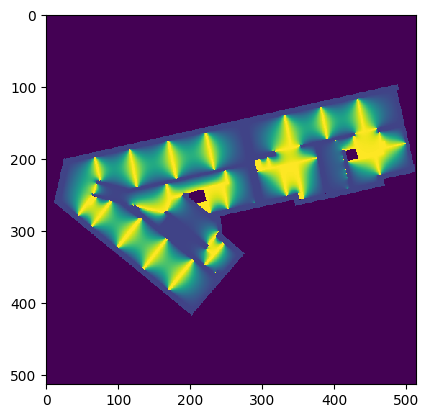

In [ ]:
u0, interior_mask = load_data(LOAD_DIR, '10000')
u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)

plt.imshow(u, interpolation='none')

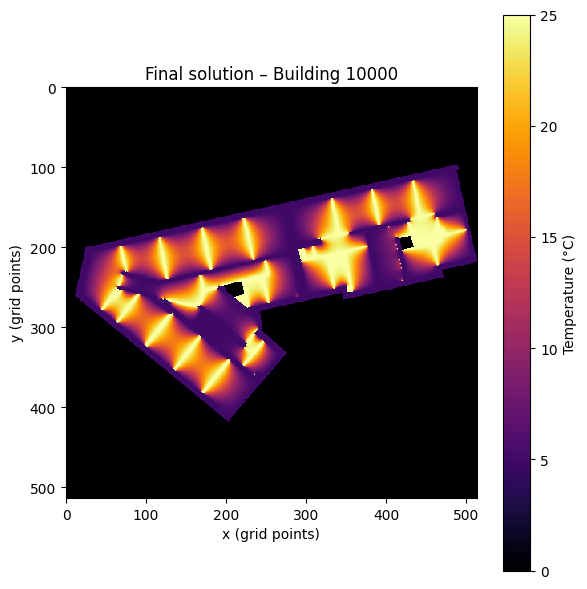

In [29]:
plt.figure(figsize=(6, 6))
plt.imshow(u, interpolation='none', cmap='inferno', vmin=0, vmax=25)
plt.colorbar(label='Temperature (°C)')
plt.title(f'Final solution – Building 10000')
plt.xlabel('x (grid points)')
plt.ylabel('y (grid points)')
plt.tight_layout()
plt.show()

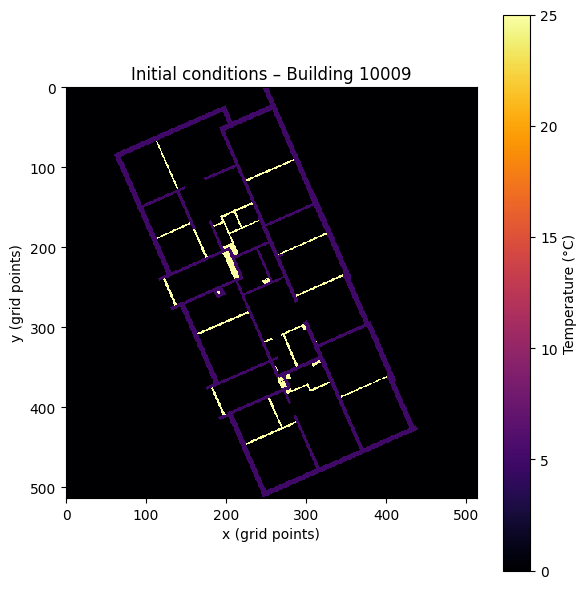

In [18]:
plt.figure(figsize=(6, 6))
plt.imshow(u0, interpolation='none', cmap='inferno', vmin=0, vmax=25)
plt.colorbar(label='Temperature (°C)')
plt.title(f'Initial conditions – Building 10009')
plt.xlabel('x (grid points)')
plt.ylabel('y (grid points)')
plt.tight_layout()
plt.show()

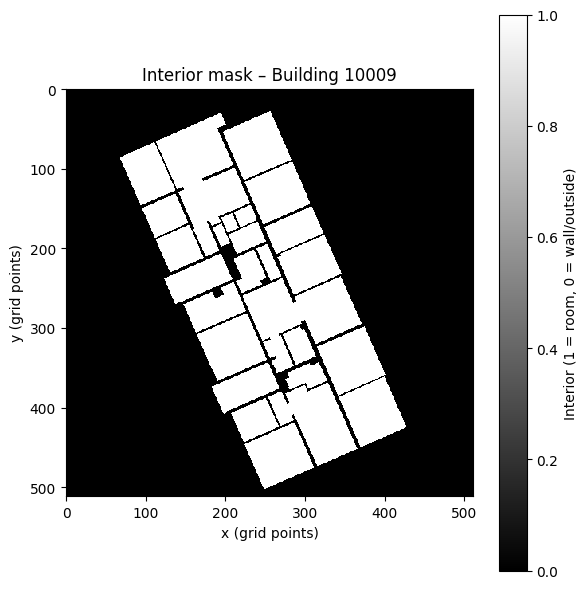

In [19]:
plt.figure(figsize=(6, 6))
plt.imshow(interior_mask, interpolation='none', cmap='gray')
plt.colorbar(label='Interior (1 = room, 0 = wall/outside)')
plt.title(f'Interior mask – Building 10009')
plt.xlabel('x (grid points)')
plt.ylabel('y (grid points)')
plt.tight_layout()
plt.show()

In [8]:
building_ids

['10000', '10009']

## plot time

In [ ]:
#reference time
buildings = np.array([5, 10, 12, 15, 17, 20])

# Raw times in seconds (converted from m:ss)
times = {
    5:  [97.396,  104.799, 105.576],
    10: [173.521, 173.015, 173.478],
    12: [238.062, 238.604, 239.620],
    15: [319.744, 317.712, 316.583],
    17: [348.811, 343.185, 344.580],
    20: [436.563, 443.102, 441.280],
}

avg_times = np.array([np.mean(times[n]) for n in buildings])


In [ ]:
# Numba

buildings = np.array([10, 13, 16, 20])

times = {
    10: [13.935, 13.718, 13.691],
    13: [21.516, 21.331, 21.252],
    16: [25.870, 26.308, 26.030],
    20: [35.115, 34.900, 34.824],
}

avg_times = np.array([np.mean(times[n]) for n in buildings])


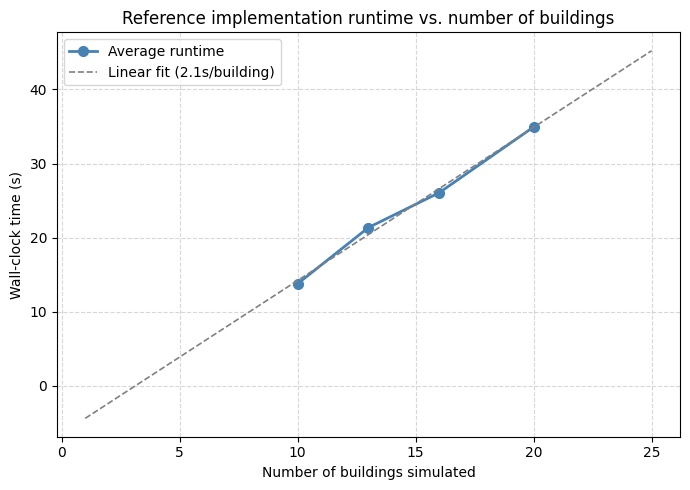

In [ ]:
# fit at line 


coeffs = np.polyfit(buildings, avg_times, 1)
fit_line = np.poly1d(coeffs)
x_fit = np.linspace(1, 25, 100)

plt.figure(figsize=(7, 5))
plt.plot(buildings, avg_times, 'o-', color='steelblue', linewidth=2, markersize=7, label='Average runtime')
plt.plot(x_fit, fit_line(x_fit), '--', color='gray', linewidth=1.2, label=f'Linear fit ({coeffs[0]:.1f}s/building)')

plt.xlabel('Number of buildings simulated')
plt.ylabel('Wall-clock time (s)')
plt.title('Reference implementation runtime vs. number of buildings')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('task2_timing.png', dpi=150)
plt.show()

In [ ]:
# total time

((coeffs[0]*4571 + coeffs[1])/60)/60

np.float64(2.6235166222729576)

In [ ]:
# coeffiencts
coeffs[0], coeffs[1]

(np.float64(2.067625570776255), np.float64(-6.456643835616436))